In [99]:
import pandas as pd
import numpy as np
import plotly.express as px
import datetime as dt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [100]:
file = "C:/Users/Asus/OneDrive/Desktop/GymIQ/realistic_synthetic_training_data.csv"
file2 = "C:/Users/Asus/OneDrive/Desktop/GymIQ/squat_dataframe.csv"
data = pd.read_csv(file)
squat_data = pd.read_csv(file2)

In [101]:
data['Date'] = pd.to_datetime(data['Date'], format = "%d-%m-%Y")

In [102]:
#We need to find 1RM to predict stregth growth
#Using Epley's Formula

data['1RM'] = (data['Weight'] * (1 + (data['Reps'] / 30)))

In [103]:
squat_df = data[data['Exercise'] == 'Squat'].copy()

squat_df['Date'] = pd.to_datetime(squat_df['Date'])
squat_df = squat_df.sort_values('Date')

squat_df = squat_df.reset_index(drop=True)
squat_df['t'] = range(len(squat_df))
squat_df

,Date,Exercise,Weight,Reps,Sets,RestSeconds,1RM,t
0,2024-01-01,Squat,100.7,5,4,180,117.483333,0
1,2024-01-03,Squat,99.6,5,4,180,116.200000,1
2,2024-01-05,Squat,99.3,5,4,180,115.850000,2
3,2024-01-08,Squat,101.2,5,4,180,118.066667,3
4,2024-01-10,Squat,99.3,5,4,180,115.850000,4
...,...,...,...,...,...,...,...,...
73,2024-06-19,Squat,114.7,5,4,180,133.816667,73
74,2024-06-21,Squat,116.9,5,4,180,136.383333,74
75,2024-06-24,Squat,114.6,5,4,180,133.700000,75
76,2024-06-26,Squat,115.8,5,4,180,135.100000,76


In [104]:
y = squat_df['1RM']
X = squat_df['t']

X = sm.add_constant(X)

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    1RM   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     942.4
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           1.40e-44
Time:                        11:48:30   Log-Likelihood:                -154.25
No. Observations:                  78   AIC:                             312.5
Df Residuals:                      76   BIC:                             317.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        117.0385      0.397    294.615      0.0

In [105]:
#B0 = Intercept
'''
Intercept = 102.81
This represents: Estimated squat 1RM at session t = 0
'''

#B1 = Slope 
'''
Slope (β₁ for t) = 1.0286
Interpretation: Your squat 1RM is increasing by ~1.03 kg per session on average.
'''
squat_df['Predicted'] = results.predict(X)

squat_df['Residual'] = squat_df['1RM'] - squat_df['Predicted']

In [106]:
squat_df

,Date,Exercise,Weight,Reps,Sets,RestSeconds,1RM,t,Predicted,Residual
0,2024-01-01,Squat,100.7,5,4,180,117.483333,0,117.038478,0.444856
1,2024-01-03,Squat,99.6,5,4,180,116.200000,1,117.311921,-1.111921
2,2024-01-05,Squat,99.3,5,4,180,115.850000,2,117.585363,-1.735363
3,2024-01-08,Squat,101.2,5,4,180,118.066667,3,117.858806,0.207860
4,2024-01-10,Squat,99.3,5,4,180,115.850000,4,118.132249,-2.282249
...,...,...,...,...,...,...,...,...,...,...
73,2024-06-19,Squat,114.7,5,4,180,133.816667,73,136.999802,-3.183136
74,2024-06-21,Squat,116.9,5,4,180,136.383333,74,137.273245,-0.889912
75,2024-06-24,Squat,114.6,5,4,180,133.700000,75,137.546688,-3.846688
76,2024-06-26,Squat,115.8,5,4,180,135.100000,76,137.820131,-2.720131


In [107]:
residual_df = squat_df[['t', '1RM', 'Predicted', 'Residual']]

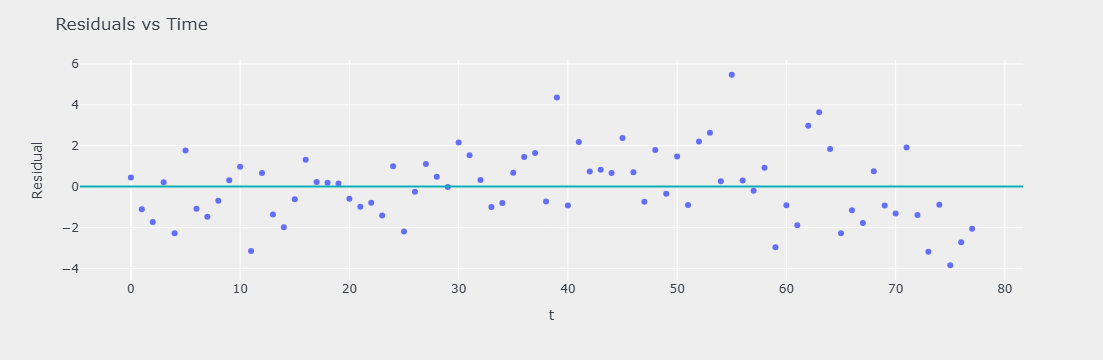

In [108]:
plot_title = 'Residuals vs Time'

residual_plot = px.scatter(
    residual_df,
    x = 't',
    y = 'Residual',
)

residual_plot.add_hline(
    y=0, 
    line_width=2, 
    line_color="#00ADB5"
)

residual_plot.update_layout(
    title = plot_title,
    plot_bgcolor = '#EEEEEE',
    paper_bgcolor = '#EEEEEE',
    font_color = '#393E46',
)


residual_plot.show()

In [109]:
squat_df['t_centered'] = squat_df['t'] - squat_df['t'].mean()
squat_df['t2'] = squat_df['t_centered']**2

X = sm.add_constant(squat_df[['t_centered', 't2']])
model_quad = sm.OLS(squat_df['1RM'], X).fit()
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                    1RM   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     577.4
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           2.80e-46
Time:                        11:48:30   Log-Likelihood:                -146.38
No. Observations:                  78   AIC:                             298.8
Df Residuals:                      75   BIC:                             305.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        128.4017      0.274    468.973      0.0

In [110]:
squat_df.head()

,Date,Exercise,Weight,Reps,Sets,RestSeconds,1RM,t,Predicted,Residual,t_centered,t2
0,2024-01-01,Squat,100.7,5,4,180,117.483333,0,117.038478,0.444856,-38.5,1482.25
1,2024-01-03,Squat,99.6,5,4,180,116.200000,1,117.311921,-1.111921,-37.5,1406.25
2,2024-01-05,Squat,99.3,5,4,180,115.850000,2,117.585363,-1.735363,-36.5,1332.25
3,2024-01-08,Squat,101.2,5,4,180,118.066667,3,117.858806,0.207860,-35.5,1260.25
4,2024-01-10,Squat,99.3,5,4,180,115.850000,4,118.132249,-2.282249,-34.5,1190.25


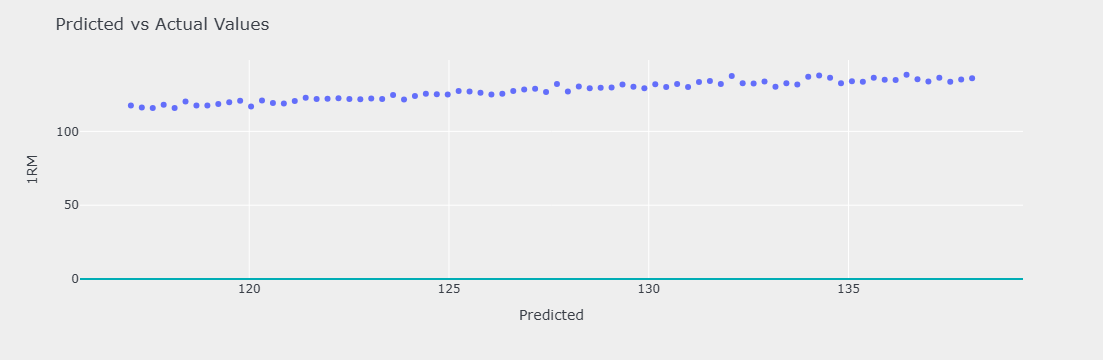

In [111]:
plot_title = 'Prdicted vs Actual Values'

multiquad_plot = px.scatter(
    squat_df,
    x = 'Predicted',
    y = '1RM',
)

multiquad_plot.add_hline(
    y=0, 
    line_width=2, 
    line_color="#00ADB5"
)

multiquad_plot.update_layout(
    title = plot_title,
    plot_bgcolor = '#EEEEEE',
    paper_bgcolor = '#EEEEEE',
    font_color = '#393E46',
)


multiquad_plot.show()

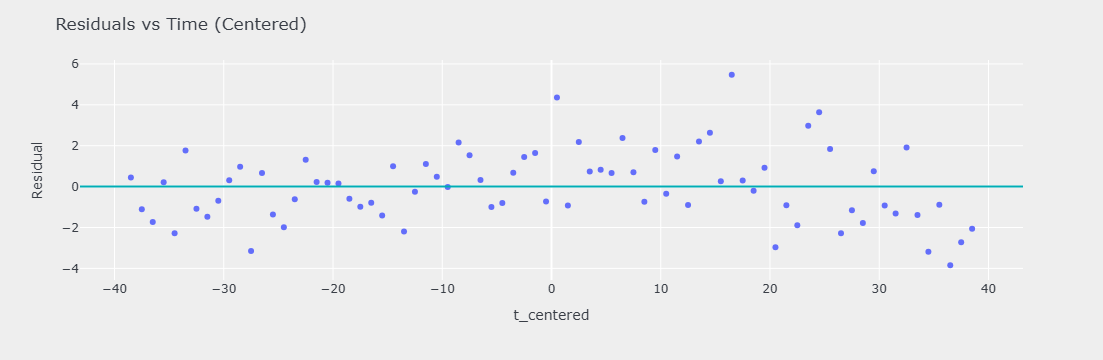

In [112]:
plot_title = 'Residuals vs Time (Centered)'

multiquad_plot = px.scatter(
    squat_df,
    x = 't_centered',
    y = 'Residual',
)

multiquad_plot.add_hline(
    y=0, 
    line_width=2, 
    line_color="#00ADB5"
)

multiquad_plot.update_layout(
    title = plot_title,
    plot_bgcolor = '#EEEEEE',
    paper_bgcolor = '#EEEEEE',
    font_color = '#393E46',
)


multiquad_plot.show()

In [113]:
squat_data = squat_data.fillna(0)

In [114]:
squat_data[["1RM", "Session ID"]].corr()

,1RM,Session ID
1RM,1.000000,0.961965
Session ID,0.961965,1.000000


In [115]:
split_index = int(len(squat_data) * 0.8)

train = squat_data.iloc[:split_index]
test = squat_data.iloc[split_index:]

In [116]:
model = LinearRegression()
model.fit(train[["Session ID"]], train["1RM"])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [117]:
predictions = model.predict(test[["Session ID"]])

In [118]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test["1RM"], predictions)
print(mae)

2.626472846713755


In [119]:
features = ["Session ID", "Fatigue Ratio"]

model.fit(train[features], train["1RM"])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [120]:
predictions2 = model.predict(test[features])

In [121]:
mae = mean_absolute_error(test["1RM"], predictions2)
print(mae)

2.153933965140509


In [122]:
features2 = ['Session ID', 'Fatigue Ratio', 'Rolling 7 Day Volume']

model.fit(train[features2], train['1RM'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [123]:
predictions3 = model.predict(test[features2])

In [124]:
mae = mean_absolute_error(test["1RM"], predictions3)
print(mae)

2.139825315265982


In [125]:
#Forecasting

last_session = squat_data['Session ID'].max()
last_session

78

In [126]:
recent_fatigue = squat_data['Fatigue Ratio'].tail(10).mean()
avg_volume = squat_data['Rolling 7 Day Volume'].mean()

In [186]:
future_sessions = np.arange(79, 111)

future_df = pd.DataFrame({
    "Session ID": future_sessions,
    "Fatigue Ratio": recent_fatigue,
    'Rolling 7 Day Volume': avg_volume
})

# Predict
future_df["Predicted 1RM"] = model.predict(future_df)

future_df.head()

,Session ID,Fatigue Ratio,Rolling 7 Day Volume,Predicted 1RM
0,79,0.252319,41805.748718,138.609859
1,80,0.252319,41805.748718,138.870021
2,81,0.252319,41805.748718,139.130184
3,82,0.252319,41805.748718,139.390347
4,83,0.252319,41805.748718,139.650509


In [128]:
#Confidence Intervals

train_preds = model.predict(train[features2])

residual = train['1RM'] - train_preds

residual_std = np.std(residual)

future_df["Lower CI"] = future_df["Predicted 1RM"] - (1.96 * residual_std)
future_df["Upper CI"] = future_df["Predicted 1RM"] + (1.96 * residual_std)

future_df.head()

,Session ID,Fatigue Ratio,Rolling 7 Day Volume,Predicted 1RM,Lower CI,Upper CI
0,79,0.252319,41805.748718,138.609859,135.754393,141.465325
1,80,0.252319,41805.748718,138.870021,136.014555,141.725487
2,81,0.252319,41805.748718,139.130184,136.274718,141.985650
3,82,0.252319,41805.748718,139.390347,136.534880,142.245813
4,83,0.252319,41805.748718,139.650509,136.795043,142.505975


In [129]:
pred = float(input('Enter target 1RM: '))

target = future_df[future_df["Lower CI"] >= pred].reset_index()

if len(target) > 0:
    target_id = int(target['Session ID'][0])
    print(f'With 95% confidence, you are expected to hit {pred}kg squat by session number {target_id}')
else:
    print("Target not achievable within forecast range.")

Enter target 1RM:  140


With 95% confidence, you are expected to hit 140.0kg squat by session number 96


In [130]:
pattern_data = pd.DataFrame()
pattern_data['Weekday'] = squat_df['Date'].dt.day_name()

In [187]:
pattern_data.head()

,Weekday,1RM,Residual,Date,Rest Days,Session ID
0,Monday,117.483333,0.444856,2024-01-01,0.0,1
1,Wednesday,116.200000,-1.111921,2024-01-03,2.0,2
2,Friday,115.850000,-1.735363,2024-01-05,2.0,3
3,Monday,118.066667,0.207860,2024-01-08,3.0,4
4,Wednesday,115.850000,-2.282249,2024-01-10,2.0,5


In [188]:
pattern_data['1RM'] = squat_df['1RM']
pattern_data.head()

,Weekday,1RM,Residual,Date,Rest Days,Session ID
0,Monday,117.483333,0.444856,2024-01-01,0.0,1
1,Wednesday,116.200000,-1.111921,2024-01-03,2.0,2
2,Friday,115.850000,-1.735363,2024-01-05,2.0,3
3,Monday,118.066667,0.207860,2024-01-08,3.0,4
4,Wednesday,115.850000,-2.282249,2024-01-10,2.0,5


In [133]:
pattern_data['Residual'] = squat_df['Residual']

In [134]:
pattern_data['Date'] = squat_df['Date']


In [141]:
highest_1rm = pattern_data.groupby('Weekday')['Residual'].mean().sort_values(ascending=False).reset_index()
highest_weekday_1rm = highest_1rm['Weekday'][0]
highest_1rm

,Weekday,Residual
0,Monday,0.295879
1,Friday,-0.138827
2,Wednesday,-0.157051


In [142]:
print(f'You Squat best on {highest_weekday_1rm}s')

You Squat best on Mondays


In [154]:
pattern_data['Rest Days'] = pattern_data['Date'].diff()
pattern_data['Rest Days'] = pattern_data['Rest Days'].dt.days.fillna(0)
pattern_data['Session ID'] = pattern_data['Date'].factorize()[0] + 1

In [155]:
pattern_data.groupby('Rest Days')['Session ID'].count()

Rest Days
0.0     1
2.0    52
3.0    25
Name: Session ID, dtype: int64

In [169]:
optimal_rest = pattern_data.groupby('Rest Days')['Residual'].mean().sort_values(ascending=False).reset_index()
res1 = (optimal_rest['Residual'][1])
res2 = (optimal_rest['Residual'][2])

opt_day = int(optimal_rest['Rest Days'][1])
second_best_day = int(optimal_rest['Rest Days'][2])

difference = res1 - res2

effect_size = difference / residual_std

In [174]:
if effect_size < 0.5:
    print(f'Slight performance benefit observed with a {opt_day} days recovery compared to {second_best_day} days')

elif effect_size >= 0.5:
    print(f'Better Performance observed with a {opt_day} days of recovery')

else:
    print(f'Need more data to verify the results')

Slight performance benefit observed with a 3 days recovery compared to 2 days


In [196]:
#Deload Week Recommendation
deload_data = pd.DataFrame()

deload_res = (
    squat_df['Residual']
    .rolling(3)
    .mean()
)

fatigue = (
    squat_data['Fatigue Ratio']
    .mean()
)


fatigue_std = (
    squat_data['Fatigue Ratio']
    .std()
)



0.1216683626878763